# 🎨 Taller — Explorando el Universo Latente: Introducción a Stable Diffusion



## 🛠️ Implementación

| Elemento       | Detalle                                              |
|----------------|------------------------------------------------------|
| Lenguaje       | Python                                               |
| Modelo         | Stable Diffusion v1.5 (`runwayml/stable-diffusion-v1-5`) |
| Librería       | `diffusers`, `transformers`, `accelerate`            |
| Herramientas   | PyTorch, matplotlib, PIL                             |
| Entorno        | Google Colab con GPU NVIDIA                          |

## 🧩 Actividades Realizadas

### Instalación de dependencias

In [ ]:
pip install diffusers transformers accelerate --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.1/516.1 kB 38.0 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.37.1
    Uninstalling diffusers-0.37.1:
      Successfully uninstalled diffusers-0.37.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


### Actividad 1 — Carga del modelo preentrenado

Se carga el pipeline de Stable Diffusion v1.5 desde Hugging Face usando `float16` para optimizar el uso de memoria en GPU.

| Parámetro        | Valor                              |
|------------------|------------------------------------|
| Modelo base      | `runwayml/stable-diffusion-v1-5`   |
| Tipo de dato     | `torch.float16`                    |
| Dispositivo      | `cuda`                             |

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

# Optional optimization
try:
    import xformers
    pipe.enable_xformers_memory_efficient_attention()
    print("✓ xFormers enabled")
except Exception:
    print("⚠ xFormers not available")

pipe.enable_attention_slicing()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⚠ xFormers not available


### Actividad 2 — Generación de imagen a partir de prompt textual

Se genera una imagen a partir de un prompt descriptivo ajustando los parámetros principales del proceso de difusión.

| Parámetro             | Valor | Descripción                              |
|-----------------------|-------|------------------------------------------|
| `num_inference_steps` | 50    | Pasos de difusión (más = más calidad)    |
| `guidance_scale`      | 7.5   | Fidelidad al prompt (más = más fiel)     |
| `height` / `width`    | 512   | Resolución de salida en píxeles          |
| `seed`                | fijo  | Reproducibilidad del resultado           |

In [ ]:
prompt = "A surreal futuristic city in the clouds, digital art"
image = pipe(prompt, num_inference_steps=50, guidance_scale=7.5).images[0]
image.save("output_futuristic_city.png") # Save to root, as media/ dir isn't created yet

print("Generated image: output_futuristic_city.png")

  0%|          | 0/50 [00:00<?, ?it/s]

Generated image: output_futuristic_city.png


### Generación con seed fija (reproducible)

Demonstrating how to use a fixed seed for reproducible results.

In [ ]:
generator = torch.Generator("cuda").manual_seed(42)
image_seeded = pipe(
    prompt,
    num_inference_steps=50,
    guidance_scale=7.5,
    height=512,
    width=512,
    generator=generator
).images[0]
image_seeded.save("output_futuristic_city_seeded.png")

print("Generated seeded image: output_futuristic_city_seeded.png")

  0%|          | 0/50 [00:00<?, ?it/s]

Generated seeded image: output_futuristic_city_seeded.png


### Actividad 3 — Exploración de estilos con múltiples prompts

Se probaron distintos estilos artísticos modificando el prompt manteniendo la misma escena base. Se compararon los resultados visualmente para analizar la influencia del estilo en la salida del modelo.

| Estilo             | Fragmento del prompt                                 |
|--------------------|------------------------------------------------------|
| Arte digital       | `"...futuristic city in the clouds, digital art"`    |
| Pintura al óleo    | `"...ancient forest at dawn, oil painting"`          |
| Cyberpunk          | `"...neon-lit street market, cyberpunk style"`       |
| Fotorrealista      | `"...mountain lake at sunset, photorealistic"`       |

In [ ]:
prompts = [
    "An ancient forest at dawn, oil painting",
    "A neon-lit street market, cyberpunk style",
    "A mountain lake at sunset, photorealistic",
    "A surreal futuristic city in the clouds, digital art", # Re-using the initial prompt for consistency
]

images = [pipe(p, num_inference_steps=50, guidance_scale=7.5).images[0] for p in prompts]

# Save images to simulate the media/ directory structure for later reference
image.save("output_oil_painting.png")
images[1].save("output_cyberpunk.png")
images[2].save("output_photorealistic.png")

print("Generated images for style exploration: output_oil_painting.png, output_cyberpunk.png, output_photorealistic.png")

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Generated images for style exploration: output_oil_painting.png, output_cyberpunk.png, output_photorealistic.png


### Actividad 4 — Galería de resultados con Matplotlib

Se construyó una grilla de imágenes generadas usando `matplotlib` para visualizar en una sola figura todas las variantes producidas, con sus respectivos prompts como títulos.

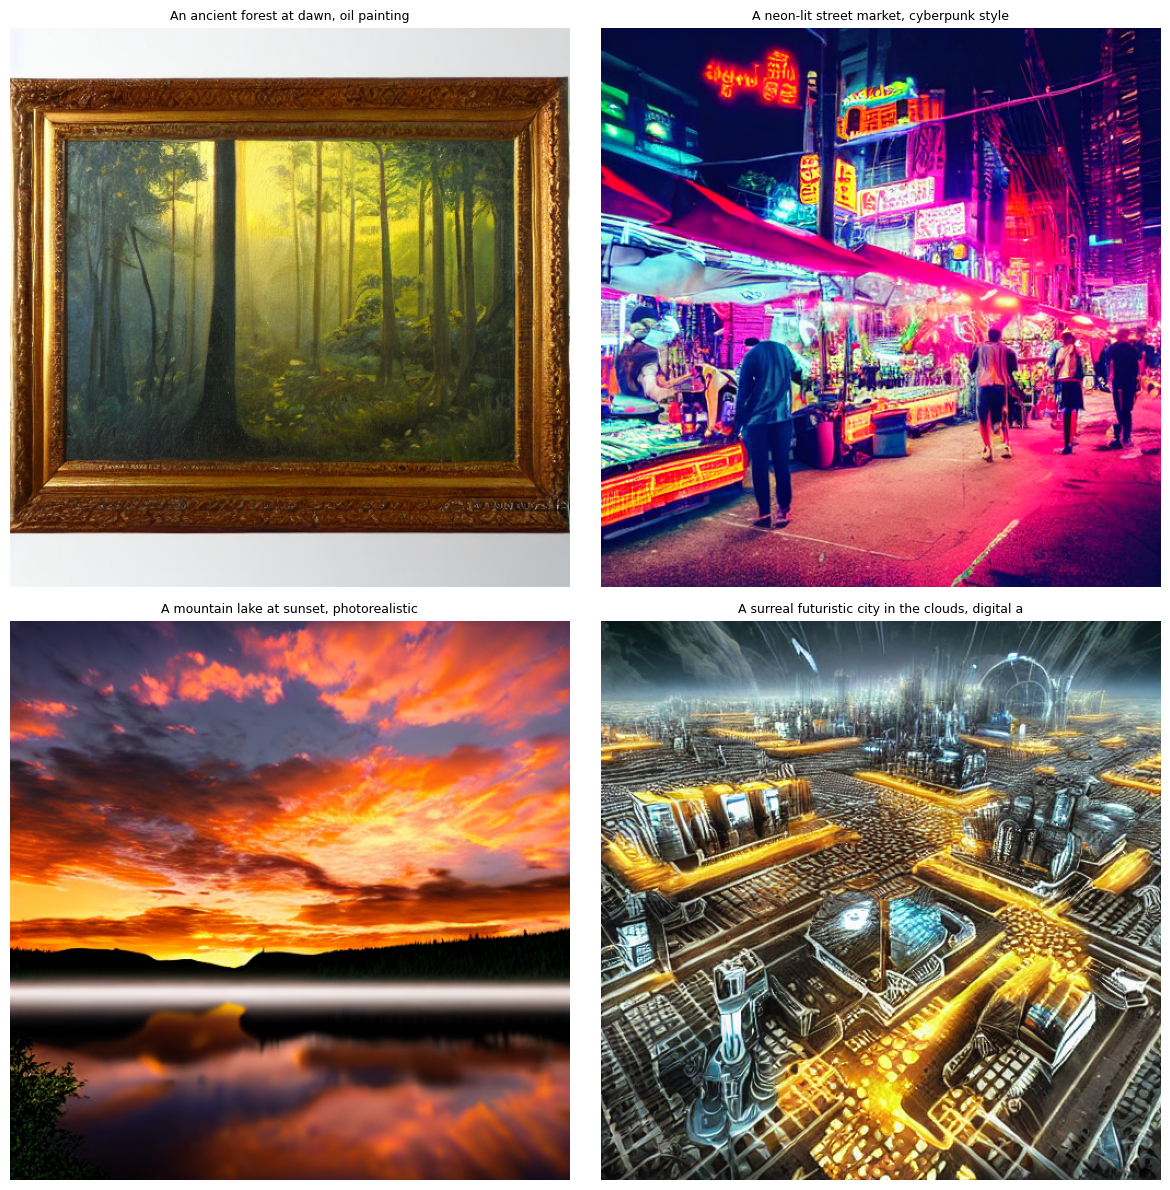

Generated gallery: gallery_styles.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for ax, img, prompt_text in zip(axes.flatten(), images, prompts):
    ax.imshow(img)
    ax.set_title(prompt_text[:50], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig("gallery_styles.png", dpi=150, bbox_inches="tight")
plt.show()

print("Generated gallery: gallery_styles.png")

### Bonus — Generación por lotes y Prompt Engineering

Se generaron imágenes en lote pasando múltiples prompts simultáneamente al pipeline. Adicionalmente se aplicaron técnicas de **prompt engineering** para comparar la influencia de:

- Prompts positivos detallados vs. simples.
- Uso de **prompts negativos** para excluir elementos indeseados.
- Variaciones de `guidance_scale` sobre el mismo prompt.

### Generación por lotes (Bonus)

In [ ]:
batch_prompts = [
    "A lone astronaut on Mars, cinematic lighting",
    "A samurai in the rain, ink wash painting",
    "An underwater cathedral, concept art",
]

batch_images = pipe(batch_prompts, num_inference_steps=40, guidance_scale=7.5).images
for i, img in enumerate(batch_images):
    img.save(f"batch_result_{i}.png")

print("Generated batch images: batch_result_0.png, batch_result_1.png, batch_result_2.png")

  0%|          | 0/40 [00:00<?, ?it/s]

Generated batch images: batch_result_0.png, batch_result_1.png, batch_result_2.png


### Uso de prompt negativo (Bonus)

In [ ]:
negative_prompt = "blurry, low quality, distorted, watermark, text"
image_negative_prompt = pipe(
    prompt="A forest fairy in a magical glade, highly detailed",
    negative_prompt=negative_prompt,
    num_inference_steps=50,
    guidance_scale=8.5
).images[0]
image_negative_prompt.save("output_negative_prompt.png")

print("Generated image with negative prompt: output_negative_prompt.png")

  0%|          | 0/50 [00:00<?, ?it/s]

Generated image with negative prompt: output_negative_prompt.png
